# Network Traffic EDA

Quick exploratory data analysis workflow for the merged dataset.

In [1]:
# Core libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display and style settings
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Basic Data Metrics

In [14]:
DATA_PATH = Path('traffic.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at: {DATA_PATH.resolve()}')

# Robust CSV load
try:
    df = pd.read_csv(DATA_PATH, low_memory=False)
except Exception as e:
    print(f'Default parser failed ({e}). Retrying with python engine...')
    df = pd.read_csv(DATA_PATH, low_memory=False, engine='python')

# Normalize column names and labels
df.columns = df.columns.str.strip()
if 'Label' in df.columns:
    df['Label'] = df['Label'].astype(str).str.strip()

print(f'Loaded dataset: {DATA_PATH.resolve()}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head(5))

Loaded dataset: C:\School projects\Security 2\traffic.csv
Shape: 2,830,743 rows x 79 columns


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
# Count duplicates and missing values
duplicates_total = df.duplicated().sum()
missing_per_col = df.isna().sum()
missing_total = missing_per_col.sum()

print(f'=== Duplicates ===')
print(f'Total duplicate rows: {duplicates_total:,}')
print(f'Percentage of duplicates: {100 * duplicates_total / len(df):.4f}%')

print(f'\n=== Missing Values ===')
print(f'Total missing cells: {missing_total:,}')
print(f'Columns with missing values: {(missing_per_col > 0).sum():,}')

if missing_total > 0:
    print(f'\nMissing values by column:')
    missing_report = missing_per_col[missing_per_col > 0].sort_values(ascending=False)
    for col, count in missing_report.items():
        pct = 100 * count / len(df)
        print(f'  {col}: {count:,} rows ({pct:.2f}%)')
else:
    print('No missing values found!')

=== Duplicates ===
Total duplicate rows: 308,381
Percentage of duplicates: 10.8940%

=== Missing Values ===
Total missing cells: 1,358
Columns with missing values: 1

Missing values by column:
  Flow Bytes/s: 1,358 rows (0.05%)


In [16]:
# Store original size
rows_before = len(df)

# Drop duplicates
df_clean = df.drop_duplicates()
rows_after_duplicates = len(df_clean)
dropped_duplicates = rows_before - rows_after_duplicates

# Drop rows with missing values
df_clean = df_clean.dropna()
rows_after_clean = len(df_clean)
dropped_missing = rows_after_duplicates - rows_after_clean

# Summary
print('=== Data Cleaning Summary ===')
print(f'Original rows: {rows_before:,}')
print(f'After removing duplicates: {rows_after_duplicates:,} (-{dropped_duplicates:,})')
print(f'After removing missing values: {rows_after_clean:,} (-{dropped_missing:,})')
print(f'Total rows removed: {rows_before - rows_after_clean:,} ({100 * (rows_before - rows_after_clean) / rows_before:.2f}%)')
print(f'\nCleaned dataset: {rows_after_clean:,} rows x {df_clean.shape[1]:,} columns')
print('\nDataset reassigned to `df`')
df = df_clean

=== Data Cleaning Summary ===
Original rows: 2,830,743
After removing duplicates: 2,522,362 (-308,381)
After removing missing values: 2,522,009 (-353)
Total rows removed: 308,734 (10.91%)

Cleaned dataset: 2,522,009 rows x 79 columns

Dataset reassigned to `df`


In [18]:
if 'Label' in df.columns:
    label_counts = df['Label'].value_counts(dropna=False)
    label_pct = 100 * label_counts / len(df)
    label_summary = pd.DataFrame({
        'Label': label_counts.index,
        'Count': label_counts.values,
        'Percentage': label_pct.values
    })
    
    print('Label distribution')
    display(label_summary)
else:
    print('No Label column found.')

Label distribution


,Label,Count,Percentage
0,BENIGN,2096134,83.113661
1,DoS Hulk,172846,6.853504
2,DDoS,128016,5.075953
3,PortScan,90819,3.601058
4,DoS GoldenEye,10286,0.407849
5,FTP-Patator,5933,0.235249
6,DoS slowloris,5385,0.213520
7,DoS Slowhttptest,5228,0.207295
8,SSH-Patator,3219,0.127636
9,Bot,1953,0.077438


C:\Users\Nacer\AppData\Local\Temp\ipykernel_11268\1777183023.py:9: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


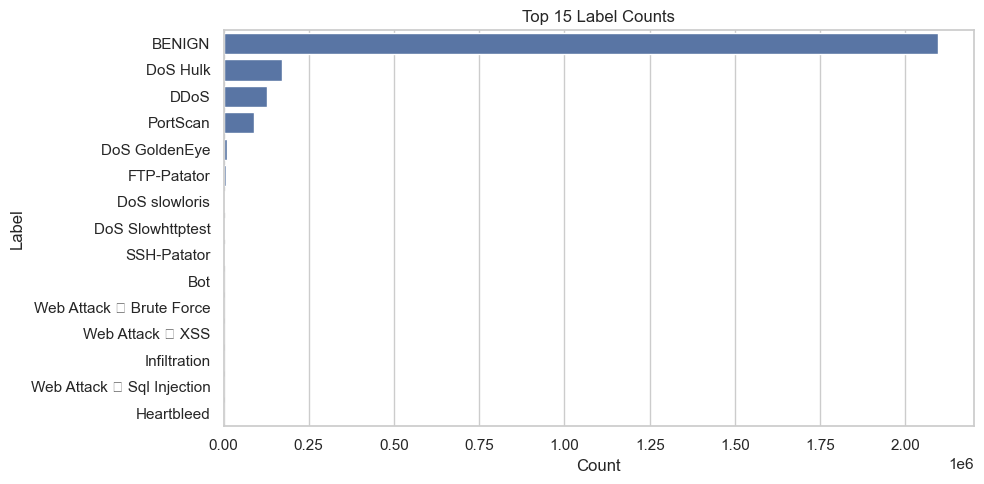

In [22]:
# Quick visual checks
if 'Label' in df.columns:
    top_labels = df['Label'].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_labels.values, y=top_labels.index)
    plt.title('Top 15 Label Counts')
    plt.xlabel('Count')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()

## Export Cleaned Dataset

In [20]:
# Export cleaned dataset to CSV
output_path = Path('clean_traffic.csv')
df.to_csv(output_path, index=False)

print(f'Cleaned dataset exported successfully!')
print(f'File: {output_path.resolve()}')
print(f'Size: {output_path.stat().st_size / (1024 ** 2):.2f} MB')
print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]:,}')

Cleaned dataset exported successfully!
File: C:\School projects\Security 2\clean_traffic.csv
Size: 842.09 MB
Rows: 2,522,009
Columns: 79
